In [51]:
import pandas as pd

files = {
    "sales": "clean_sales.csv",
    "customers": "clean_customer.csv",
    "products": "clean_product.csv",
    "stores": "clean_store.csv",
    "employees": "clean_employee.csv"
}

dfs = {}

for name, file in files.items():
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip().str.lower()
    dfs[name] = df

sales     = dfs["sales"]
customers = dfs["customers"]
products  = dfs["products"]
stores    = dfs["stores"]
employees = dfs["employees"]

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [52]:
sales.head()

,sale_id,customer_id,product_id,store_id,employee_id,sale_date,quantity,unit_price,total_price,payment_method,shipping_cost,year,month,month_name,quarter,weekday
0,1,954,164,13,93,2023-01-23,4,231.06,924.24,Cash,28.08,2023,1,Jan,1,Monday
1,2,376,22,12,109,2020-04-23,1,24.80,24.80,Credit Card,27.50,2020,4,Apr,2,Thursday
2,3,559,197,31,53,2022-07-16,6,467.22,2803.32,Debit Card,15.77,2022,7,Jul,3,Saturday
3,4,803,452,20,56,2021-04-28,4,212.47,849.88,Cash,10.60,2021,4,Apr,2,Wednesday
4,5,238,241,42,84,2020-12-18,7,284.98,1994.86,Cash,22.01,2020,12,Dec,4,Friday


## The overall KPIs

In [53]:
kpis = {
    "Total Transactions": len(sales),
    "Total Revenue": sales["total_price"].sum(),
    "Avg Order Value": sales["total_price"].mean(),
    "Units Sold": sales["quantity"].sum(),
    "Avg Shipping Cost": sales["shipping_cost"].mean(),
    "Unique Customers": sales["customer_id"].nunique(),
    "Unique Products": sales["product_id"].nunique()
}

kpis

{'Total Transactions': 550000,
 'Total Revenue': 764345617.8299998,
 'Avg Order Value': 1389.7193051454542,
 'Units Sold': 3026845,
 'Avg Shipping Cost': 23.973285309090908,
 'Unique Customers': 1000,
 'Unique Products': 500}

## Revenue Distribution

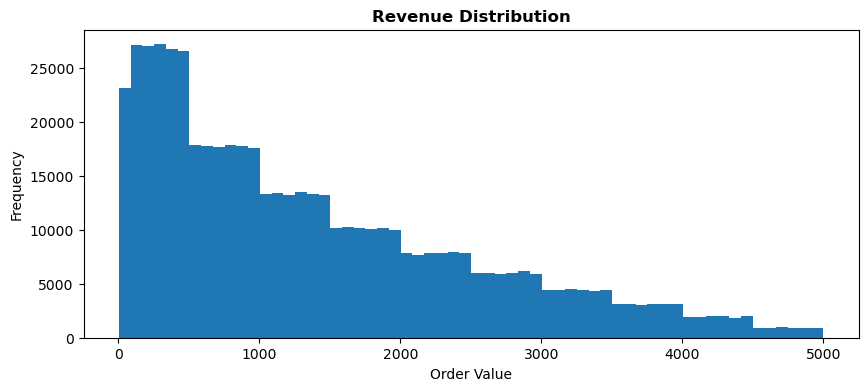

In [54]:
plt.figure(figsize=(10,4))
plt.hist(sales['total_price'], bins=60)
plt.title("Revenue Distribution", weight='bold')
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

## Monthly Revenue Trend

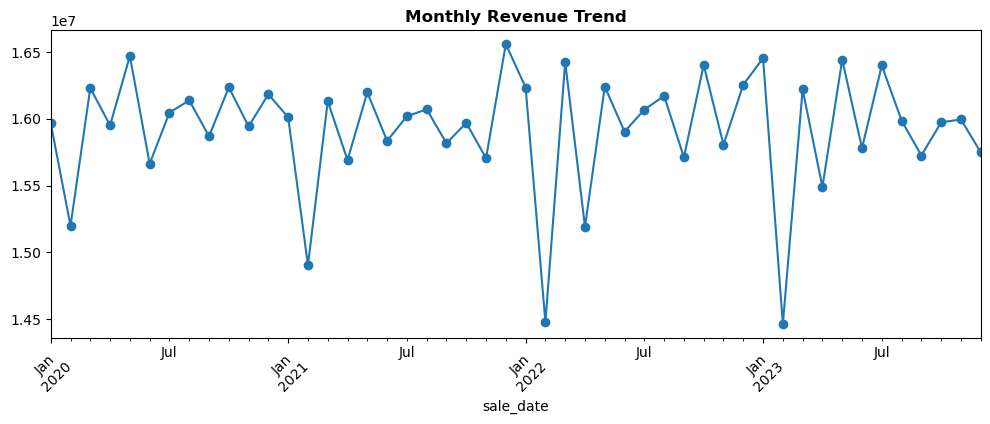

In [57]:
# Convert to datetime
sales['sale_date'] = pd.to_datetime(sales['sale_date'])
monthly = sales.groupby(sales['sale_date'].dt.to_period('M'))['total_price'].sum()
import matplotlib.pyplot as plt
monthly.plot(figsize=(12,4), marker='o')
plt.title("Monthly Revenue Trend", weight='bold')
plt.xticks(rotation=45)
plt.show()

## Yearly Revenue

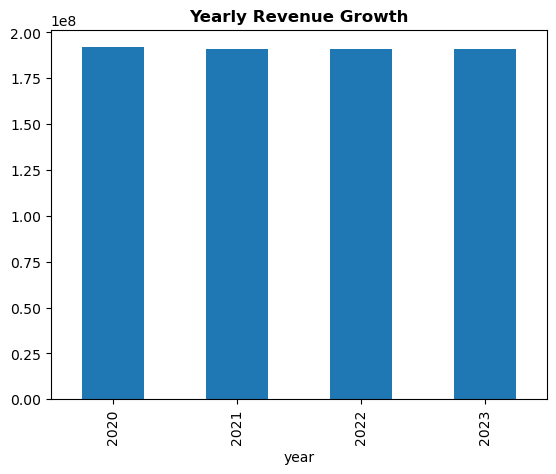

In [58]:
sales.groupby('year')['total_price'].sum().plot(kind='bar')
plt.title("Yearly Revenue Growth", weight='bold')
plt.show()

## Revenue by Region

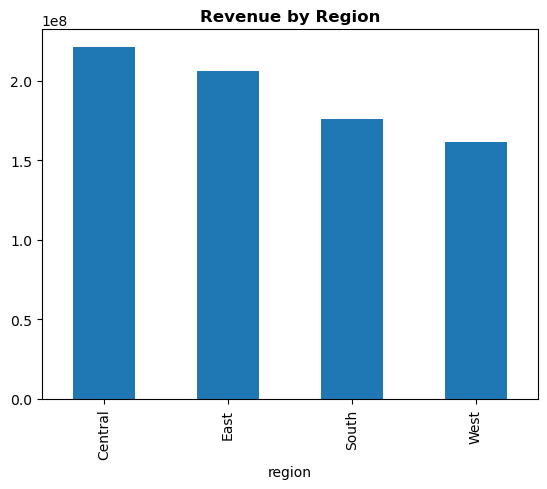

In [59]:
df = sales.merge(stores, on='store_id')
df.groupby('region')['total_price'].sum().plot(kind='bar')
plt.title("Revenue by Region", weight='bold')
plt.show()

## Store Type Performance

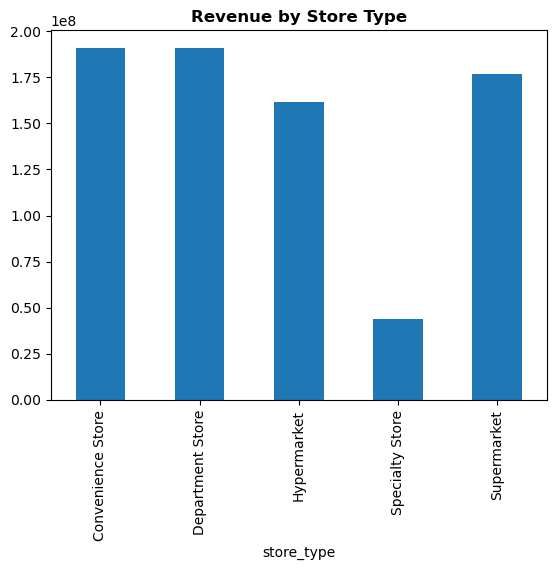

In [60]:
df.groupby('store_type')['total_price'].sum().plot(kind='bar')
plt.title("Revenue by Store Type", weight='bold')
plt.show()

## Category Performance

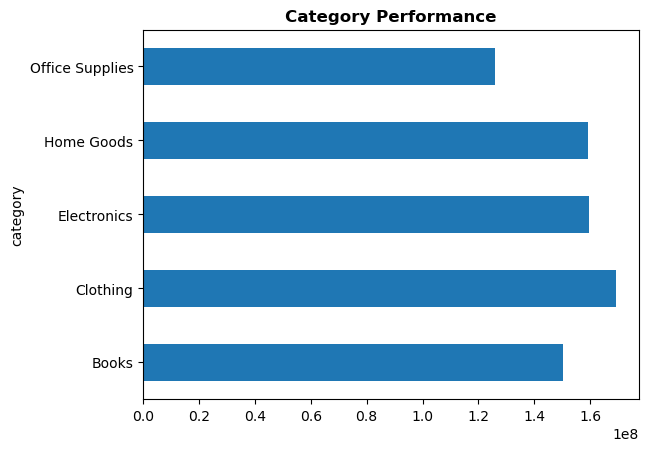

In [61]:
df2 = sales.merge(products, on='product_id')
df2.groupby('category')['total_price'].sum().plot(kind='barh')
plt.title("Category Performance", weight='bold')
plt.show()

# Sub-category Analysis

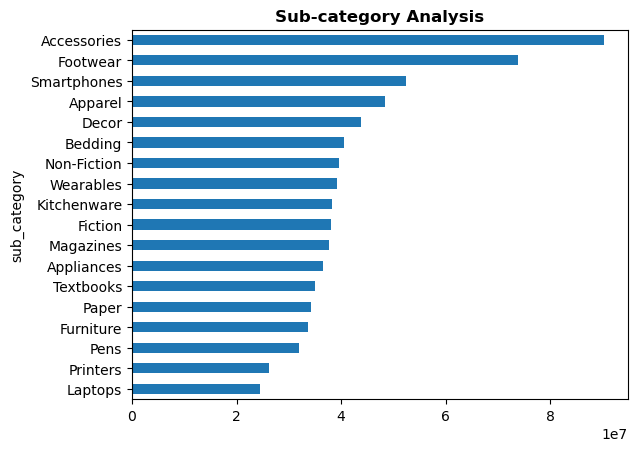

In [62]:
df2.groupby('sub_category')['total_price'].sum().sort_values().plot(kind='barh')
plt.title("Sub-category Analysis", weight='bold')
plt.show()

## CUSTOMER VALUE ANALYSIS (LTV)

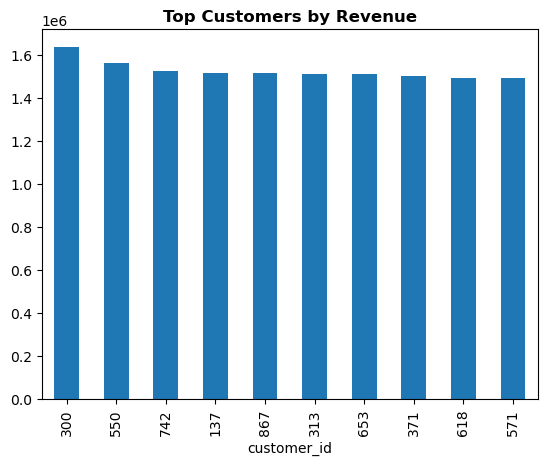

In [63]:
top_customers = sales.groupby('customer_id')['total_price'].sum().nlargest(10)

top_customers.plot(kind='bar')
plt.title("Top Customers by Revenue", weight='bold')
plt.show()

## CUSTOMER SEGMENT ANALYSIS

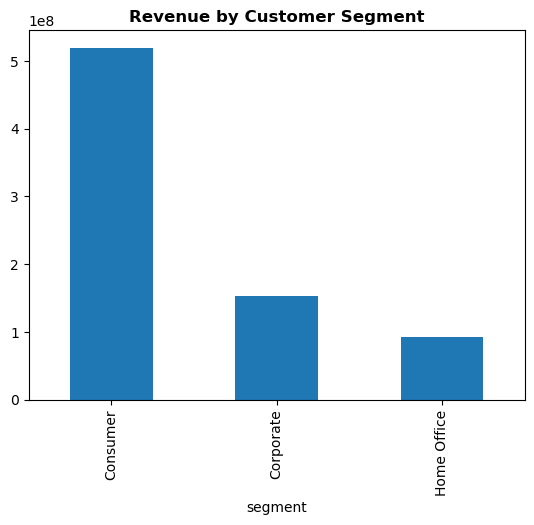

In [64]:
df3 = sales.merge(customers, on='customer_id')

df3.groupby('segment')['total_price'].sum().plot(kind='bar')
plt.title("Revenue by Customer Segment", weight='bold')
plt.show()

## AGE GROUP ANALYSIS

C:\Users\krise\AppData\Local\Temp\ipykernel_53412\3910069874.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df3.groupby('age_group')['total_price'].sum().plot(kind='bar')


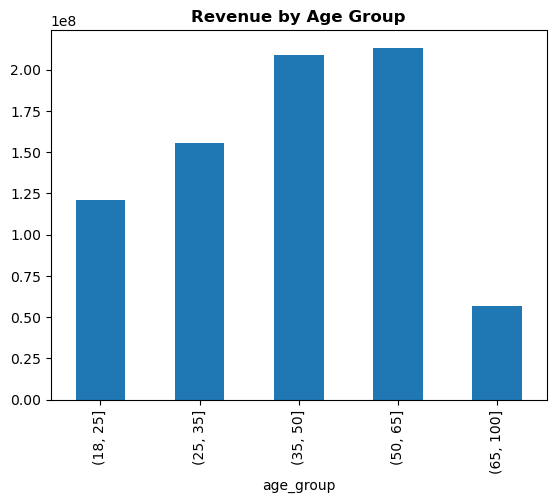

In [65]:
df3['age_group'] = pd.cut(df3['age'], bins=[18,25,35,50,65,100])
df3.groupby('age_group')['total_price'].sum().plot(kind='bar')
plt.title("Revenue by Age Group", weight='bold')
plt.show()

## PAYMENT METHOD ANALYSIS

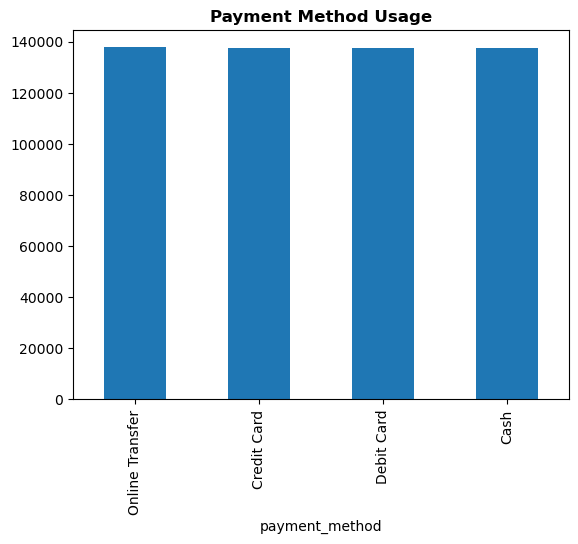

In [66]:
sales['payment_method'].value_counts().plot(kind='bar')
plt.title("Payment Method Usage", weight='bold')
plt.show()

## SHIPPING COST IMPACT

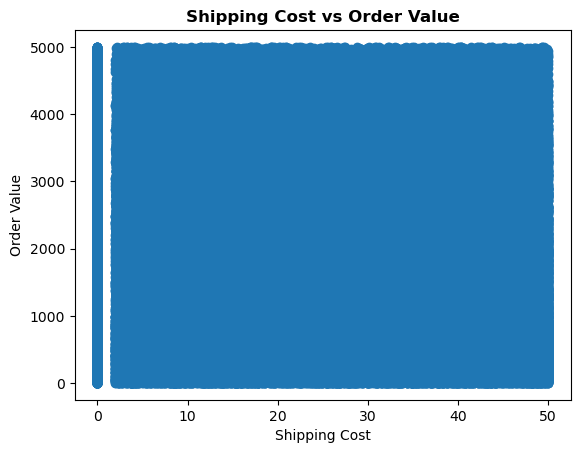

In [67]:
plt.scatter(sales['shipping_cost'], sales['total_price'])
plt.title("Shipping Cost vs Order Value", weight='bold')
plt.xlabel("Shipping Cost")
plt.ylabel("Order Value")
plt.show()

## EMPLOYEE PERFORMANCE

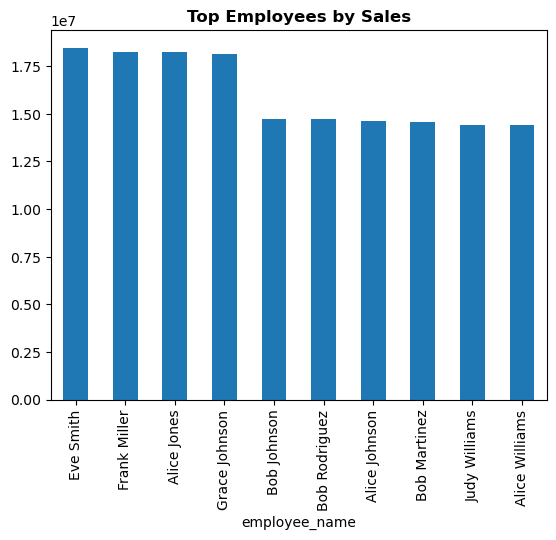

In [68]:
df4 = sales.merge(employees, on='employee_id')
df4.groupby('employee_name')['total_price'].sum().nlargest(10).plot(kind='bar')
plt.title("Top Employees by Sales", weight='bold')
plt.show()

## DAY-OF-WEEK ANALYSIS

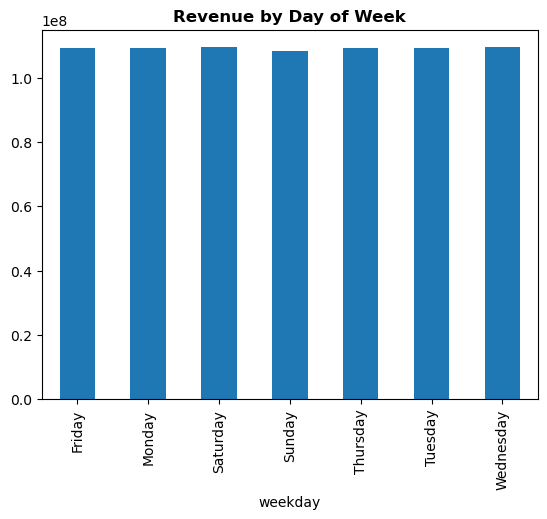

In [69]:
sales.groupby('weekday')['total_price'].sum().plot(kind='bar')
plt.title("Revenue by Day of Week", weight='bold')
plt.show()